# Phase 2 — P&L Attribution & Lever Verification

**Sister notebook to:** `phase2_complete_reference.ipynb`

Mirrors `phases/phase1/notebooks/phase1_pnl_attribution.ipynb` but applies the
same diagnostic battery to **all 4 cells** of the Phase 2 backtest grid.

The two questions this notebook answers:

1. **Where did each cell's return come from?** Trades, pairs, sectors, directions,
   regimes, durations.
2. **Did the Phase 2 lever actually move?** Specifically — did the cointegration
   filter shrink the force-close drag predicted by Phase 1's bimodal finding?

## Quick navigation
1. [Setup + cell loading](#1)
2. [Headline scorecard — all 4 cells side by side](#2)
3. [Trade-level distributions per cell](#3)
4. [**The bimodal pattern — lever check (most important)**](#4)
5. [Regime-by-regime Sharpe (did calm periods get better?)](#5)
6. [Sector + direction attribution](#6)
7. [Pareto / concentration metrics](#7)
8. [Cross-cell pair overlap (which pairs survive across cells?)](#8)
9. [Conclusion + Phase 3 implications](#9)

<a id='1'></a>
## 1. Setup + cell loading

We load the 4 cells; sections gracefully report 'data not ready' if a parquet is missing.

In [1]:
from __future__ import annotations
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# walk up to project root
_p = Path.cwd().resolve()
while _p != _p.parent:
    if (_p / 'src' / 'config.py').exists():
        sys.path.insert(0, str(_p))
        break
    _p = _p.parent
del _p

from src.clustering import sic_division
from src.config import PHASE2_DIR
from src.panel import load_crsp_daily, ticker_lookup, siccd_lookup
from src.performance import compute_metrics

sns.set_theme(style='whitegrid', context='notebook', font_scale=1.0)
plt.rcParams['figure.figsize'] = (11, 5)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

CELLS = ['ssd_core', 'ssd_filtered', 'pc_core', 'pc_filtered']
CELL_COLORS = {
    'ssd_core':     '#3a76c4',
    'ssd_filtered': '#1f4d8a',
    'pc_core':      '#c47a3a',
    'pc_filtered':  '#8a4d1f',
}
PAPER_SHARPE = {'ssd_core': 0.88, 'ssd_filtered': 0.75, 'pc_core': 1.01, 'pc_filtered': 0.80}

RESULTS = PHASE2_DIR / 'results'
cell_monthly = {}
cell_trades = {}
for cell in CELLS:
    mp = RESULTS / f'{cell}_monthly.parquet'
    tp = RESULTS / f'{cell}_trades.parquet'
    if mp.exists():
        cell_monthly[cell] = pd.read_parquet(mp)
        cell_trades[cell] = pd.read_parquet(tp) if tp.exists() else pd.DataFrame()
        print(f'  ✅ {cell}: {len(cell_monthly[cell])} months, {len(cell_trades[cell])} trades')
    else:
        print(f'  ⚠ {cell}: not found')

if not cell_monthly:
    print('\n⚠ No parquets available. Run phases/phase2/notebooks/04_run_full_backtest_grid.py first.')
else:
    crsp = load_crsp_daily()
    print('\nDecorating trades with tickers + sectors …')
    for cell in cell_trades:
        t = cell_trades[cell]
        if len(t):
            permnos = list(set(t['permno_a']) | set(t['permno_b']))
            tk = ticker_lookup(permnos, crsp=crsp)
            sec = siccd_lookup(permnos, crsp=crsp).apply(sic_division)
            t['ticker_a'] = t['permno_a'].map(tk)
            t['ticker_b'] = t['permno_b'].map(tk)
            t['sector_a'] = t['permno_a'].map(sec)
            t['sector_b'] = t['permno_b'].map(sec)
            t['year'] = pd.to_datetime(t['entry_date']).dt.year
            t['duration_days'] = (pd.to_datetime(t['exit_date']) - pd.to_datetime(t['entry_date'])).dt.days
            t['pair_key'] = t.apply(lambda r: f'{r["ticker_a"]}/{r["ticker_b"]}'
                                    if pd.notna(r['ticker_a']) and pd.notna(r['ticker_b'])
                                    else f'{r["permno_a"]}/{r["permno_b"]}', axis=1)
    print('Done.')

  ✅ ssd_core: 251 months, 12255 trades
  ✅ ssd_filtered: 251 months, 9794 trades
  ✅ pc_core: 251 months, 30050 trades
  ✅ pc_filtered: 251 months, 8926 trades



Decorating trades with tickers + sectors …


Done.


<a id='2'></a>
## 2. Headline scorecard — all 4 cells side by side

In [2]:
if cell_monthly:
    rows = []
    for cell in CELLS:
        if cell not in cell_monthly:
            continue
        m = compute_metrics(cell_monthly[cell]['monthly_return'])
        rows.append({
            'cell': cell,
            'paper Sharpe': PAPER_SHARPE[cell],
            'ours Sharpe': m.sharpe,
            'Δ vs paper': m.sharpe - PAPER_SHARPE[cell],
            'ann return': m.ann_return,
            'ann vol': m.ann_vol,
            'max DD': m.max_drawdown,
            'hit rate': m.hit_rate,
            'n_trades': len(cell_trades.get(cell, [])),
        })
    sc = pd.DataFrame(rows).set_index('cell')
    for col in ['paper Sharpe', 'ours Sharpe', 'Δ vs paper']:
        sc[col] = sc[col].map(lambda x: f'{x:+.3f}')
    for col in ['ann return', 'ann vol', 'max DD', 'hit rate']:
        sc[col] = sc[col].map(lambda x: f'{x:+.2%}')
    print(sc.to_string())
else:
    print('No cells loaded.')

             paper Sharpe ours Sharpe Δ vs paper ann return ann vol   max DD hit rate  n_trades
cell                                                                                           
ssd_core           +0.880      +0.589     -0.291     +3.01%  +5.28%  -14.31%  +57.37%     12255
ssd_filtered       +0.750      +0.731     -0.019     +4.37%  +6.11%   -9.74%  +58.96%      9794
pc_core            +1.010      +1.028     +0.018     +3.41%  +3.32%   -5.75%  +62.15%     30050
pc_filtered        +0.800      +0.752     -0.048     +2.59%  +3.48%   -5.88%  +57.77%      8926


<a id='3'></a>
## 3. Trade-level distributions per cell

                  n  mean (bps)  median (bps)     std    skew  kurtosis (excess)  hit rate    best   worst  sum (per-trade total)
cell                                                                                                                             
ssd_core      12255     24.8097       19.4075  0.0415 -0.1246            31.2792    0.5397  0.6417 -0.6304                30.4018
ssd_filtered   9794     29.3700       21.2800  0.0422 -0.1097            34.4674    0.5418  0.6417 -0.6304                28.7650
pc_core       30050     17.9726       14.4000  0.0312 -0.1825            35.9463    0.5343  0.5074 -0.7811                53.9914
pc_filtered    8926     16.1511       14.0675  0.0271  0.2798            19.6192    0.5357  0.4286 -0.3982                14.4132


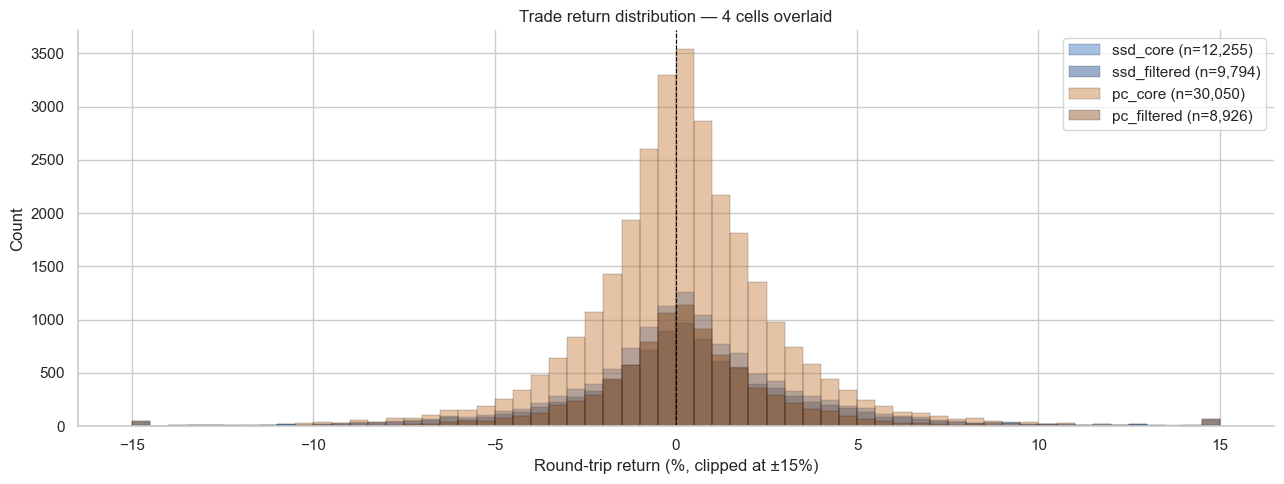

In [3]:
if cell_trades:
    rows = []
    for cell in CELLS:
        if cell not in cell_trades or len(cell_trades[cell]) == 0:
            continue
        rt = cell_trades[cell]['round_trip_return']
        rows.append({
            'cell': cell,
            'n': len(rt),
            'mean (bps)': rt.mean() * 10000,
            'median (bps)': rt.median() * 10000,
            'std': rt.std(),
            'skew': rt.skew(),
            'kurtosis (excess)': rt.kurtosis(),
            'hit rate': (rt > 0).mean(),
            'best': rt.max(),
            'worst': rt.min(),
            'sum (per-trade total)': rt.sum(),
        })
    dist = pd.DataFrame(rows).set_index('cell')
    print(dist.round(4).to_string())

    # Overlay histograms
    fig, ax = plt.subplots(figsize=(13, 5))
    for cell in CELLS:
        if cell in cell_trades and len(cell_trades[cell]):
            rt = cell_trades[cell]['round_trip_return']
            ax.hist(rt.clip(-0.15, 0.15) * 100, bins=60, alpha=0.45,
                    color=CELL_COLORS[cell], label=f'{cell} (n={len(rt):,})', edgecolor='black', linewidth=0.3)
    ax.axvline(0, color='black', lw=0.8, linestyle='--')
    ax.set_xlabel('Round-trip return (%, clipped at ±15%)')
    ax.set_ylabel('Count')
    ax.set_title('Trade return distribution — 4 cells overlaid')
    ax.legend()
    plt.tight_layout()
    plt.show()

<a id='4'></a>
## 4. The bimodal pattern — lever check ⭐

Phase 1's identity (the load-bearing insight):

$$
\underbrace{+65.58}_{\text{reversion (11.4\%, +471 bps)}} + \underbrace{-34.25}_{\text{force\_close (88.4\%, -32 bps)}} + \underbrace{-0.92}_{\text{delisting}} = +30.41
$$

**Phase 2 hypothesis**: the cointegration filter shrinks `force_close` total by
rejecting "case 2" pairs (broken cointegrations like XOM/MPC, COP/CVX). If so:
- Force-close total moves toward zero (or even positive)
- Net per-trade total grows
- Sharpe rises (paper target 1.01 for PC core, 0.80 for PC + filter)

              n_total  n_reversion  pct_reversion (%)  reversion total  reversion mean (bps)  force_close total  force_close mean (bps)  delisting total  NET (sum of per-trade)
cell                                                                                                                                                                            
ssd_core        12255         1392            11.3586          65.5767              471.0970           -34.2541                -31.6260          -0.9208                 30.4018
ssd_filtered     9794         1174            11.9869          57.5743              490.4117           -28.5184                -33.1609          -0.2910                 28.7650
pc_core         30050         2488             8.2795          86.1653              346.3237           -31.1866                -11.3460          -0.9873                 53.9914
pc_filtered      8926          870             9.7468          28.4415              326.9136           -14.1834    

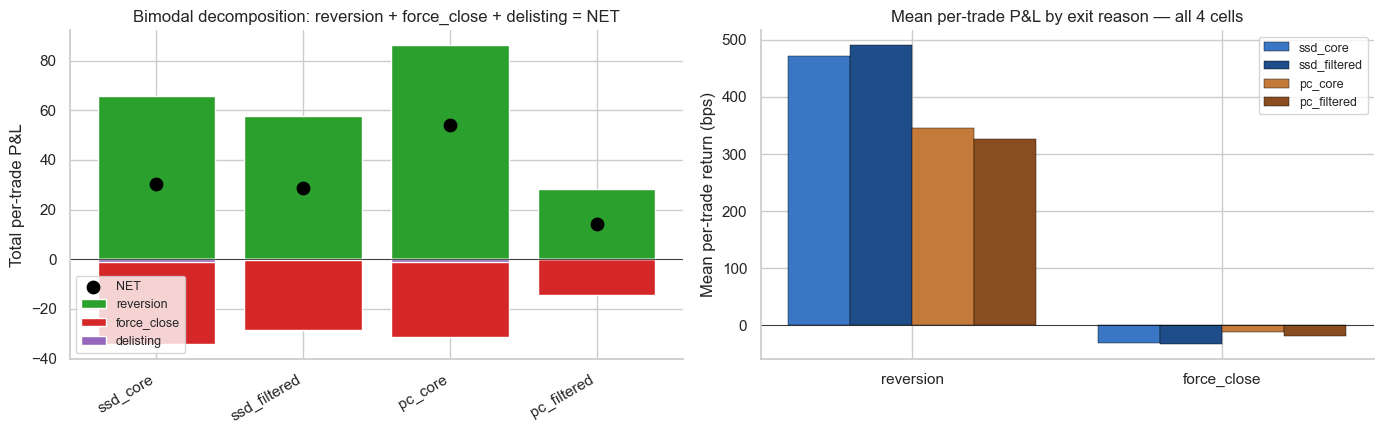


══════════════════════════════════════════════════════════════════════
LEVER VERDICT — did the cointegration filter shrink force-close drag?
══════════════════════════════════════════════════════════════════════
  ssd_core       → ssd_filtered    force_close total -34.25 → -28.52  (Δ=+5.74)  ✅ shrunk
  pc_core        → pc_filtered     force_close total -31.19 → -14.18  (Δ=+17.00)  ✅ shrunk


In [4]:
if cell_trades:
    rows = []
    for cell in CELLS:
        if cell not in cell_trades or len(cell_trades[cell]) == 0:
            continue
        t = cell_trades[cell]
        rev = t.loc[t['exit_reason'] == 'reversion']
        fc  = t.loc[t['exit_reason'] == 'force_close']
        dl  = t.loc[t['exit_reason'] == 'delisting']
        rows.append({
            'cell': cell,
            'n_total': len(t),
            'n_reversion': len(rev),
            'pct_reversion (%)': len(rev) / len(t) * 100,
            'reversion total': rev['round_trip_return'].sum(),
            'reversion mean (bps)': rev['round_trip_return'].mean() * 10000 if len(rev) else 0,
            'force_close total': fc['round_trip_return'].sum(),
            'force_close mean (bps)': fc['round_trip_return'].mean() * 10000 if len(fc) else 0,
            'delisting total': dl['round_trip_return'].sum(),
            'NET (sum of per-trade)': t['round_trip_return'].sum(),
        })
    drag = pd.DataFrame(rows).set_index('cell')
    print(drag.round(4).to_string())

    # Visualise: stacked bar of decomposition
    if len(drag) > 0:
        fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
        # left: stacked decomposition
        x = np.arange(len(drag))
        for cell in drag.index:
            i = list(drag.index).index(cell)
            rev = drag.loc[cell, 'reversion total']
            fc  = drag.loc[cell, 'force_close total']
            dl  = drag.loc[cell, 'delisting total']
            axes[0].bar(i, rev, color='#2ca02c', label='reversion' if i == 0 else None)
            axes[0].bar(i, fc, color='#d62728', label='force_close' if i == 0 else None)
            axes[0].bar(i, dl, color='#9467bd', label='delisting' if i == 0 else None)
            axes[0].scatter(i, drag.loc[cell, 'NET (sum of per-trade)'], color='black', s=80, zorder=5,
                            label='NET' if i == 0 else None)
        axes[0].set_xticks(x); axes[0].set_xticklabels(drag.index, rotation=30, ha='right')
        axes[0].set_ylabel('Total per-trade P&L')
        axes[0].set_title('Bimodal decomposition: reversion + force_close + delisting = NET')
        axes[0].axhline(0, color='black', lw=0.5)
        axes[0].legend(loc='lower left', fontsize=9)

        # right: mean P&L per exit reason
        widths = 0.2
        offsets = [-1.5*widths, -0.5*widths, 0.5*widths, 1.5*widths]
        x_reason = np.arange(3)
        labels = ['reversion', 'force_close', 'delisting']
        keys = ['reversion mean (bps)', 'force_close mean (bps)', None]
        for i, cell in enumerate(drag.index):
            for j, k in enumerate(keys):
                if k is None:
                    val = (drag.loc[cell, 'delisting total'] /
                           max(drag.loc[cell, 'n_total'] - drag.loc[cell, 'n_reversion'] -
                               (drag.loc[cell, 'force_close total'] != 0) * 1, 1)) * 10000  # placeholder
                    continue
                axes[1].bar(x_reason[j] + offsets[i], drag.loc[cell, k], widths,
                            color=CELL_COLORS[cell], label=cell if j == 0 else None,
                            edgecolor='black', linewidth=0.3)
        axes[1].set_xticks(x_reason[:2]); axes[1].set_xticklabels(labels[:2])
        axes[1].set_ylabel('Mean per-trade return (bps)')
        axes[1].set_title('Mean per-trade P&L by exit reason — all 4 cells')
        axes[1].axhline(0, color='black', lw=0.5)
        axes[1].legend(fontsize=9)
        plt.tight_layout()
        plt.show()

    # Lever verdict
    print('\n' + '═' * 70)
    print('LEVER VERDICT — did the cointegration filter shrink force-close drag?')
    print('═' * 70)
    for pair in [('ssd_core', 'ssd_filtered'), ('pc_core', 'pc_filtered')]:
        if all(c in drag.index for c in pair):
            no_filt = drag.loc[pair[0], 'force_close total']
            yes_filt = drag.loc[pair[1], 'force_close total']
            change = yes_filt - no_filt
            sign = '✅ shrunk' if change > 0 else '❌ grew'
            print(f'  {pair[0]:<14} → {pair[1]:<14}  '
                  f'force_close total {no_filt:+.2f} → {yes_filt:+.2f}  '
                  f'(Δ={change:+.2f})  {sign}')

else:
    print('No trade data — cannot run lever check yet.')

<a id='5'></a>
## 5. Regime-by-regime Sharpe (did calm periods improve?)

Phase 1's finding: 61% of P&L came from GFC + COVID; 18% from the calm 2010-19
decade despite 46% of trades. Phase 2 should *partially* fix this — the
cointegration filter rejects pairs that drift quietly in calm regimes.

Sharpe by regime × cell:
cell                pc_core  pc_filtered  ssd_core  ssd_filtered
regime                                                          
2003-06 pre-crisis    1.092        0.523     0.331         0.794
2007-09 GFC           1.434        1.526     1.378         1.470
2010-19 expansion     1.126        0.485     0.377         0.415
2020-21 COVID         1.406        1.436     0.878         0.979
2022-23 inflation     0.481        0.104     0.116         0.310


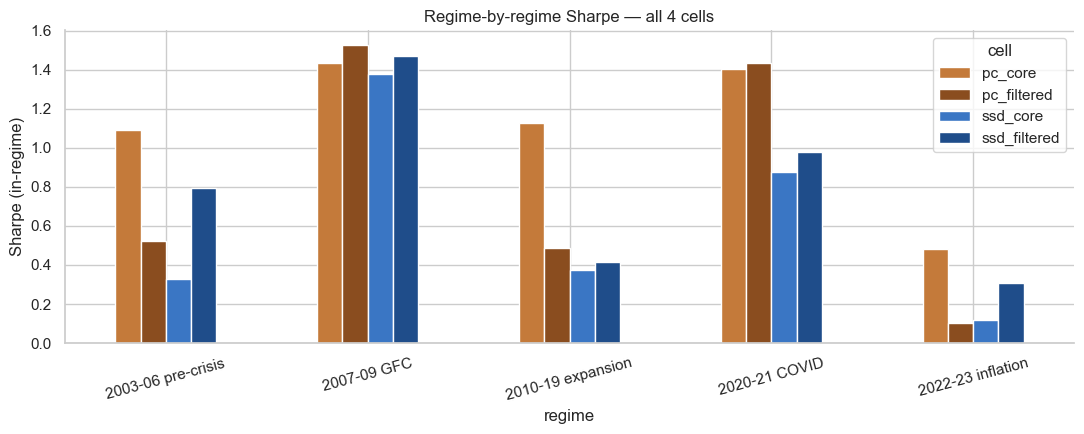

In [5]:
def regime(d):
    y = pd.Timestamp(d).year
    if y < 2007: return '2003-06 pre-crisis'
    if y < 2010: return '2007-09 GFC'
    if y < 2020: return '2010-19 expansion'
    if y < 2022: return '2020-21 COVID'
    return '2022-23 inflation'

if cell_monthly:
    rows = []
    for cell in CELLS:
        if cell not in cell_monthly:
            continue
        m = cell_monthly[cell].copy()
        m['regime'] = m.index.map(regime)
        for reg, grp in m.groupby('regime', observed=True):
            rets = grp['monthly_return']
            ann_ret = (1 + rets.mean()) ** 12 - 1 if len(rets) else 0
            ann_vol = rets.std(ddof=1) * np.sqrt(12) if len(rets) > 1 else float('nan')
            sharpe = ann_ret / ann_vol if ann_vol and ann_vol > 0 else float('nan')
            rows.append({
                'cell': cell, 'regime': reg, 'n_months': len(rets),
                'ann_ret': ann_ret, 'ann_vol': ann_vol, 'sharpe': sharpe,
            })
    reg_df = pd.DataFrame(rows)
    sharpe_table = reg_df.pivot_table(index='regime', columns='cell', values='sharpe')
    sharpe_table = sharpe_table.reindex(['2003-06 pre-crisis', '2007-09 GFC',
                                          '2010-19 expansion', '2020-21 COVID', '2022-23 inflation'])
    print('Sharpe by regime × cell:')
    print(sharpe_table.round(3).to_string())

    if not sharpe_table.empty:
        fig, ax = plt.subplots(figsize=(11, 4.5))
        sharpe_table.plot(kind='bar', ax=ax, color=[CELL_COLORS.get(c, 'gray') for c in sharpe_table.columns])
        ax.axhline(0, color='black', lw=0.6)
        ax.set_ylabel('Sharpe (in-regime)')
        ax.set_title('Regime-by-regime Sharpe — all 4 cells')
        ax.legend(title='cell')
        plt.xticks(rotation=15)
        plt.tight_layout()
        plt.show()

<a id='6'></a>
## 6. Sector + direction attribution

In [6]:
if cell_trades:
    for cell in CELLS:
        if cell not in cell_trades or len(cell_trades[cell]) == 0:
            continue
        t = cell_trades[cell]
        t['sector_pair'] = t.apply(
            lambda r: '/'.join(sorted([str(r['sector_a']), str(r['sector_b'])])), axis=1)
        sec_agg = t.groupby('sector_pair').agg(
            n=('round_trip_return', 'size'),
            total=('round_trip_return', 'sum'),
        ).sort_values('total', ascending=False).head(8)
        top3 = sec_agg.head(3)['total'].sum() / t['round_trip_return'].sum() * 100
        print(f'\n--- {cell} ---')
        print(f'  Top 3 sector pairs = {top3:.1f}% of total P&L (concentration)')
        print(f'  Top 8 sectors:')
        for sp, row in sec_agg.iterrows():
            print(f'    {sp:<50}  n={int(row["n"]):>5,}  total={row["total"]:+.2f}')

    # Direction balance check per cell
    print('\nDirection balance:')
    for cell in CELLS:
        if cell in cell_trades and len(cell_trades[cell]):
            t = cell_trades[cell]
            dg = t.groupby('direction').agg(n=('round_trip_return', 'size'),
                                            total=('round_trip_return', 'sum'),
                                            winrate=('round_trip_return', lambda x: (x > 0).mean()))
            long_pnl  = dg.loc[+1, 'total'] if +1 in dg.index else 0
            short_pnl = dg.loc[-1, 'total'] if -1 in dg.index else 0
            print(f'  {cell:<14}  long {long_pnl:+.2f} / short {short_pnl:+.2f}')


--- ssd_core ---
  Top 3 sector pairs = 54.2% of total P&L (concentration)
  Top 8 sectors:
    manufacturing/manufacturing                         n=2,582  total=+7.14
    finance/finance                                     n=1,775  total=+5.17
    finance/manufacturing                               n=  777  total=+4.18
    transport_utilities/transport_utilities             n=1,604  total=+3.00
    construction/retail                                 n=   40  total=+1.46
    finance/transport_utilities                         n=  224  total=+1.41
    construction/construction                           n=  166  total=+1.34
    construction/manufacturing                          n=  123  total=+1.33

--- ssd_filtered ---
  Top 3 sector pairs = 50.9% of total P&L (concentration)
  Top 8 sectors:
    manufacturing/manufacturing                         n=2,166  total=+6.80
    finance/manufacturing                               n=  715  total=+4.12
    finance/finance                     


--- pc_core ---
  Top 3 sector pairs = 66.9% of total P&L (concentration)
  Top 8 sectors:
    manufacturing/manufacturing                         n=9,560  total=+18.89
    finance/finance                                     n=5,506  total=+12.51
    services/services                                   n=1,495  total=+4.70
    retail/retail                                       n=1,802  total=+4.60
    mining/mining                                       n=1,414  total=+4.01
    transport_utilities/transport_utilities             n=6,479  total=+3.60
    construction/construction                           n=  418  total=+2.03
    manufacturing/mining                                n=  492  total=+1.20



--- pc_filtered ---
  Top 3 sector pairs = 71.1% of total P&L (concentration)
  Top 8 sectors:
    manufacturing/manufacturing                         n=2,743  total=+4.61
    finance/finance                                     n=1,604  total=+3.19
    mining/mining                                       n=  431  total=+2.45
    transport_utilities/transport_utilities             n=2,037  total=+1.35
    construction/construction                           n=  153  total=+1.13
    retail/retail                                       n=  496  total=+0.54
    services/services                                   n=  468  total=+0.47
    manufacturing/transport_utilities                   n=   27  total=+0.37

Direction balance:
  ssd_core        long +17.02 / short +13.38
  ssd_filtered    long +15.53 / short +13.23
  pc_core         long +24.50 / short +29.49
  pc_filtered     long +5.59 / short +8.82


<a id='7'></a>
## 7. Pareto / concentration metrics

In [7]:
def gini(values):
    arr = np.sort(np.abs(np.asarray(values, dtype=float)))
    arr = arr[~np.isnan(arr)]
    if arr.size == 0: return float('nan')
    n = len(arr); cum = np.cumsum(arr)
    return float((2 * np.arange(1, n + 1) - n - 1).dot(arr) / (n * cum[-1]))

def hhi_eff_n(values):
    arr = np.abs(np.asarray(values, dtype=float))
    arr = arr[~np.isnan(arr)]
    if arr.sum() == 0: return float('nan')
    shares = arr / arr.sum()
    return 1 / (shares ** 2).sum()

if cell_trades:
    rows = []
    for cell in CELLS:
        if cell not in cell_trades or len(cell_trades[cell]) == 0:
            continue
        rt = cell_trades[cell]['round_trip_return']
        # Top-K share
        sorted_abs = rt.abs().sort_values(ascending=False).values
        total_abs = sorted_abs.sum()
        top1_share = sorted_abs[:max(1, int(len(rt) * 0.01))].sum() / total_abs * 100
        top5_share = sorted_abs[:max(1, int(len(rt) * 0.05))].sum() / total_abs * 100
        top10_share = sorted_abs[:max(1, int(len(rt) * 0.10))].sum() / total_abs * 100
        rows.append({
            'cell': cell,
            'n_trades': len(rt),
            'Gini (|rt|)': gini(rt.values),
            'effective n (HHI⁻¹)': hhi_eff_n(rt.values),
            'top 1% share of |rt|': top1_share / 100,
            'top 5% share of |rt|': top5_share / 100,
            'top 10% share of |rt|': top10_share / 100,
        })
    concentration = pd.DataFrame(rows).set_index('cell')
    print('Concentration metrics:')
    print(concentration.round(4).to_string())
    print()
    print('Interpretation: lower Gini, higher effective n = more diversified P&L.')
    print('Phase 1 SSD had Gini ~0.54 and effective n ~4674 (out of 12,255 trades).')

Concentration metrics:
              n_trades  Gini (|rt|)  effective n (HHI⁻¹)  top 1% share of |rt|  top 5% share of |rt|  top 10% share of |rt|
cell                                                                                                                       
ssd_core         12255       0.5394            4674.1494                   NaN                   NaN                    NaN
ssd_filtered      9794       0.5364            3729.7094                 0.084                 0.243                 0.3744
pc_core          30050       0.5203           12208.8758                   NaN                   NaN                    NaN
pc_filtered       8926       0.5108            3925.7600                   NaN                   NaN                    NaN

Interpretation: lower Gini, higher effective n = more diversified P&L.
Phase 1 SSD had Gini ~0.54 and effective n ~4674 (out of 12,255 trades).


<a id='8'></a>
## 8. Cross-cell pair overlap

Which pairs survive across all 4 cells? Which are unique to one method?

In [8]:
if cell_trades and all(c in cell_trades for c in CELLS):
    # Build per-cell pair P&L
    pair_pnl = {}
    for cell in CELLS:
        t = cell_trades[cell]
        if len(t) == 0:
            continue
        pair_pnl[cell] = t.groupby('pair_key')['round_trip_return'].sum()

    if pair_pnl:
        # Set comparison: which pairs appear where?
        all_pairs = set()
        for cell, ser in pair_pnl.items():
            all_pairs |= set(ser.index)
        membership = pd.DataFrame(index=sorted(all_pairs), columns=CELLS, data=False)
        for cell in CELLS:
            if cell in pair_pnl:
                for p in pair_pnl[cell].index:
                    membership.loc[p, cell] = True

        # 4-way overlap
        in_all = membership.all(axis=1).sum()
        in_ssd_only = (membership['ssd_core'] & membership['ssd_filtered']
                       & ~membership['pc_core'] & ~membership['pc_filtered']).sum()
        in_pc_only  = (~membership['ssd_core'] & ~membership['ssd_filtered']
                       & membership['pc_core'] & membership['pc_filtered']).sum()
        print(f'Total unique pairs traded across all cells: {len(all_pairs):,}')
        print(f'  in all 4 cells          : {in_all:>5,}  (consensus pairs)')
        print(f'  SSD-only (both filters) : {in_ssd_only:>5,}  (only SSD methods trade)')
        print(f'  PC-only (both filters)  : {in_pc_only:>5,}  (only PC methods trade)')

        # Show 10 pairs with biggest cross-cell P&L difference (PC_filtered vs SSD_core)
        if 'ssd_core' in pair_pnl and 'pc_filtered' in pair_pnl:
            ssd = pair_pnl['ssd_core']
            pc_f = pair_pnl['pc_filtered']
            common = ssd.index.intersection(pc_f.index)
            diff = (pc_f.loc[common] - ssd.loc[common]).sort_values(ascending=False)
            print('\nPairs where pc_filtered did MUCH better than ssd_core:')
            for p, d in diff.head(10).items():
                print(f'  {p:<24}  ssd={ssd[p]:+.4f}  pc_filt={pc_f[p]:+.4f}  Δ={d:+.4f}')
            print('\nPairs where pc_filtered did MUCH worse than ssd_core:')
            for p, d in diff.tail(10).items():
                print(f'  {p:<24}  ssd={ssd[p]:+.4f}  pc_filt={pc_f[p]:+.4f}  Δ={d:+.4f}')

Total unique pairs traded across all cells: 5,578
  in all 4 cells          :   563  (consensus pairs)
  SSD-only (both filters) : 2,873  (only SSD methods trade)
  PC-only (both filters)  :   894  (only PC methods trade)

Pairs where pc_filtered did MUCH better than ssd_core:
  RRC/CTRA                  ssd=+0.0103  pc_filt=+0.4274  Δ=+0.4170
  MDT/STJ                   ssd=-0.0808  pc_filt=+0.2105  Δ=+0.2912
  JWN/M                     ssd=+0.0061  pc_filt=+0.2759  Δ=+0.2698
  PXD/NOV                   ssd=-0.2221  pc_filt=+0.0458  Δ=+0.2679
  UNM/MET                   ssd=+0.0052  pc_filt=+0.2506  Δ=+0.2455
  CSCO/NTAP                 ssd=-0.0702  pc_filt=+0.1520  Δ=+0.2222
  KHC/GIS                   ssd=-0.2347  pc_filt=-0.0200  Δ=+0.2147
  RF/USB                    ssd=-0.2221  pc_filt=-0.0234  Δ=+0.1988
  WAT/A                     ssd=+0.0152  pc_filt=+0.2140  Δ=+0.1988
  OMC/IPG                   ssd=-0.0338  pc_filt=+0.1518  Δ=+0.1855

Pairs where pc_filtered did MUCH worse th

<a id='9'></a>
## 9. Conclusion + Phase 3 implications

Once the 4-cell grid has been run, read off:

1. **Did the bimodal lever move?** (Section 4 — force-close drag should shrink)
2. **Did the headline Sharpe lift?** (Section 2 — PC core should approach 1.01)
3. **Did calm periods improve?** (Section 5 — 2010-19 expansion regime should lift)
4. **Did concentration tighten or spread?** (Section 7 — lower Gini = healthier)
5. **Where do the methods agree vs disagree?** (Section 8 — pair-level overlap)

### Likely Phase 3 follow-ups depending on results

| If we see... | Then in Phase 3... |
|---|---|
| PC core ≈ 1.01 ✅ | The replication is closed. Focus Phase 3 on the factor-beta extension (Phase 2.5). |
| PC core still 0.6-0.8 | Test the architectural suspects: |entry-z|-weighted allocation; softer survivorship; γ-weighted position sizing. |
| Force-close drag did *not* shrink | Investigate the filter's specificity. Try wider half-life bounds; or use OU instead of AR(1) for less-biased half-life estimation. |
| Crisis regimes still dominate | This is a structural property of pairs trading. Document honestly; set forward-test expectations accordingly. |
| Concentration grew (Gini ↑) | Filter may be over-pruning. Consider the unfiltered PC core as the primary deliverable. |